# Проект - прогнозирование заказов такси

## Цель проекта: спрогнозировать количество заказов такси на следующий час

## План проекта: 
1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделайть выводы.

## Описание данных:
- Датасет:
 - 1 столбец дата
 - 2 столбец(num_orders) количество заказов

### 1. Загрузка данных, ресемплирование по 1 часу

In [1]:
# подключаем библиотеки

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np

from statsmodels.tools.sm_exceptions import InterpolationWarning

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from catboost import CatBoostRegressor

In [2]:
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [3]:
# загрузка данных

data = pd.read_csv('/datasets/taxi.csv', index_col = [0], parse_dates = [0])

In [4]:
# просмотр данных и размерности

print(data.head())
print(f'Размер: {data.shape}')

                     num_orders
datetime                       
2018-03-01 00:00:00           9
2018-03-01 00:10:00          14
2018-03-01 00:20:00          28
2018-03-01 00:30:00          20
2018-03-01 00:40:00          32
Размер: (26496, 1)


In [5]:
# проверка индекса на монотонность

print(data.index.is_monotonic)

True


In [6]:
# делаем ресемпл на 1 час

data = round(data.resample('1H').sum(), 1)

In [7]:
# проверка

print(data.head())

                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43


**Вывод по первому разделу:**
- Загрузили данные  
- Проверили на монотонность
- Сделали ресемплирование по 1 часу

### 2. Анализ данных

#### 2.1 Первичный осмотр

In [8]:
# проверим пропуски

print(data.isna().sum())

num_orders    0
dtype: int64


Пропусков нет

In [9]:
# тип данных индекса

print(data.index.dtype)

datetime64[ns]


Индекс - datetime

In [10]:
# начало и конец таймфрейма

print(data.index.min())
print(data.index.max())

2018-03-01 00:00:00
2018-08-31 23:00:00


Данные представленны с 01-03-2018 по 31-08-2018

#### 2.2 Описательная статистика

In [11]:
# мин, макс, среднее, медиана

print(f'Минимальное значение: \033[1m{data["num_orders"].min()}\033[0m заказов в час')
print(f'Максимальное значение: \033[1m{data["num_orders"].max()}\033[0m заказов в час')
print(f'Среднее значение: \033[1m{data["num_orders"].mean():.1f}\033[0m заказов в час')
print(f'Медианное значение: \033[1m{data["num_orders"].median()}\033[0m заказов в час')

Минимальное значение: 0 заказов в час
Максимальное значение: 462 заказов в час
Среднее значение: 84.4 заказов в час
Медианное значение: 78.0 заказов в час


In [12]:
# стандартное отклонение, дисперсия

print(f'Стандартное отклонение: \033[1m{round(data["num_orders"].std(), 1)}\033[0m заказов в час')
print(f'Дисперсия: \033[1m{data["num_orders"].var():.2f}\033[0m')
print(f'''Квантили: 
\033[1m{data["num_orders"].quantile([0.25, 0.5, 0.75]).to_string()}\033[0m''')
print(f'Коэффициент вариации: \033[1m{data["num_orders"].std() / data["num_orders"].mean() * 100:.2f}%\033[0m')

Стандартное отклонение: 45.0 заказов в час
Дисперсия: 2027.15
Квантили: 
0.25     54.0
0.50     78.0
0.75    107.0
Коэффициент вариации: 53.33%


#### 2.3 Визуализация

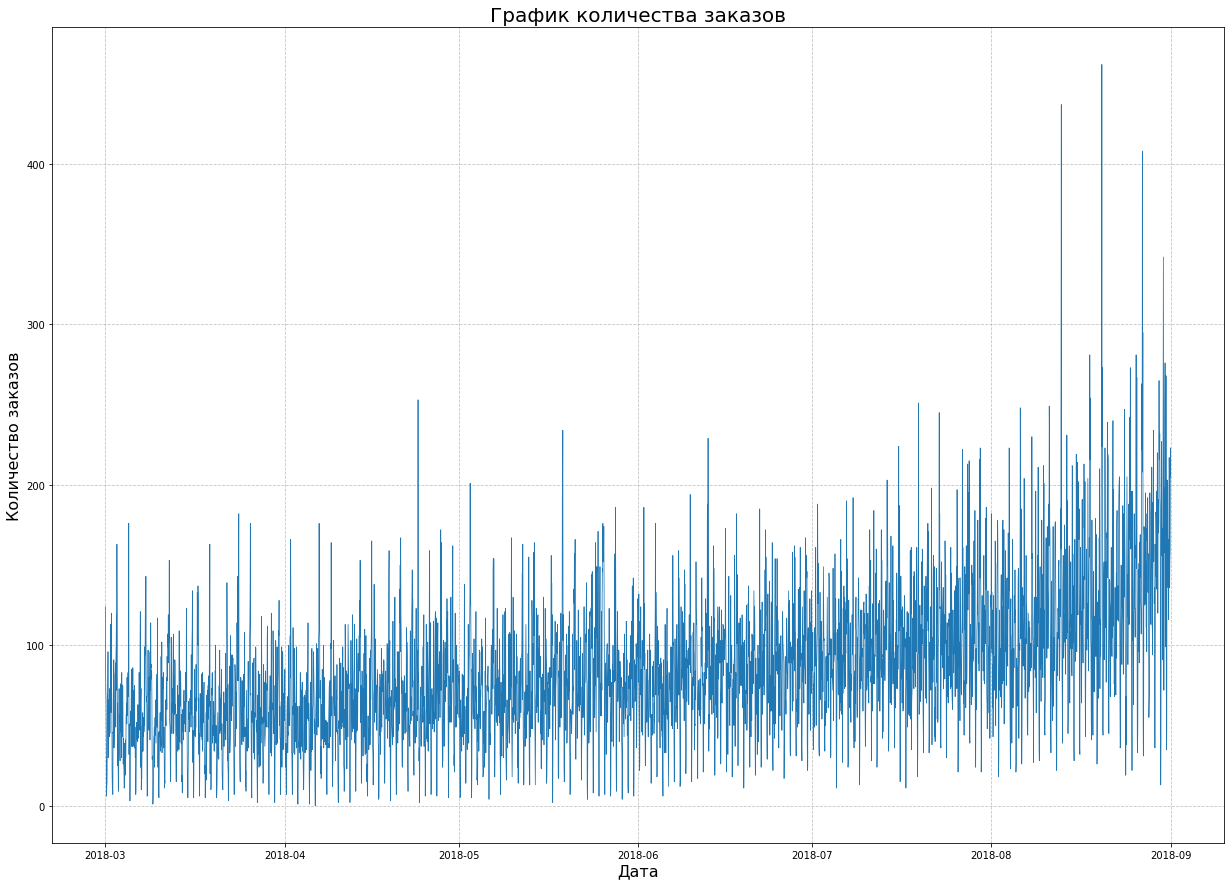

In [13]:
# график ряда

plt.figure(figsize = (21, 15))
plt.plot(data, linewidth = 0.75)
plt.grid(True, linestyle = '--', alpha = 0.75)
plt.title('График количества заказов', fontsize = 20)
plt.xlabel('Дата', fontsize = 16)
plt.ylabel('Количество заказов', fontsize = 16);

Временной ряд с 1 марта по 31 августа 2018. Наблюдаются значительные колебания. Так же наблюдается восходящий постоянный тренд.

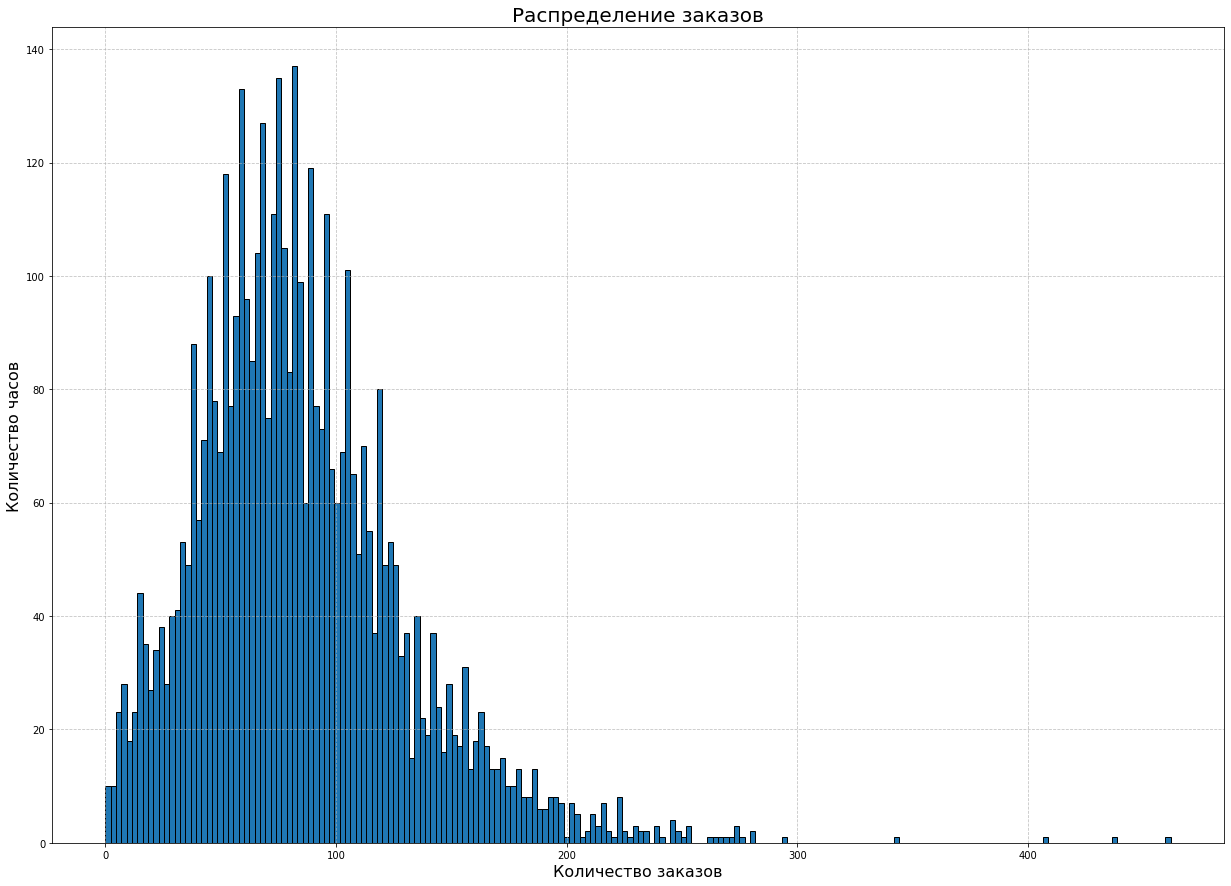

In [14]:
# гистограмма распределения

plt.figure(figsize = (21, 15))
plt.hist(data, bins = 200, edgecolor = 'black')
plt.grid(True, linestyle = '--', alpha = 0.75)
plt.title('Распределение заказов', fontsize = 20)
plt.xlabel('Количество заказов', fontsize = 16)
plt.ylabel('Количество часов', fontsize = 16);

Распределение заказов нормальное, но с правосторонней ассиметрией. Наблюдаются редкие выбросы.

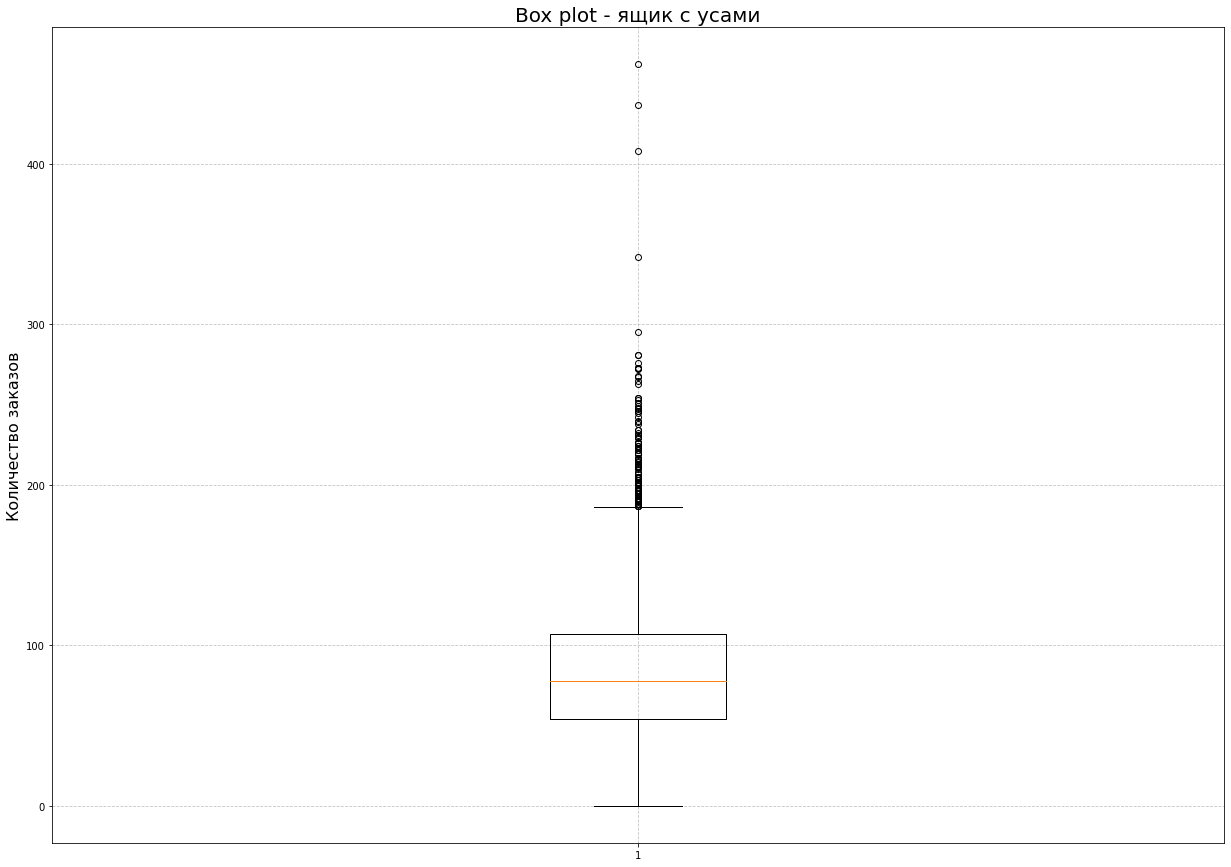

In [15]:
# boxplot, ящик с усами

plt.figure(figsize = (21, 15))
plt.boxplot(data)
plt.grid(True, linestyle = '--', alpha = 0.75)
plt.title('Box plot - ящик с усами', fontsize = 20)
plt.ylabel('Количество заказов', fontsize = 16);

In [16]:
# выбросы

outliers = data[data['num_orders'] > 31].copy()
outliers['date'] = outliers.index.date

print(f'Всего часов - выбросов: \033[1m{len(outliers)}\033[0m')
print(f'Процентное соотношение выбросов: \033[1m{len(outliers) / len(data) * 100:.2f}%\033[0m')
print('--' * 30)
print(f'Топ дат с выбросами:\n\033[1m{outliers["date"].value_counts().head(15).to_string()}\033[0m')

Всего часов - выбросов: 4037
Процентное соотношение выбросов: 91.42%
------------------------------------------------------------
Топ дат с выбросами:
2018-07-18    24
2018-07-31    24
2018-08-17    24
2018-07-22    24
2018-07-25    24
2018-08-21    24
2018-06-25    24
2018-08-31    24
2018-07-14    24
2018-08-07    24
2018-07-13    24
2018-08-10    24
2018-07-20    24
2018-08-22    24
2018-06-13    24


Ящик с усами подтверждает выводы гистограммы. Основная масса данных в интервале 9 - 18 заказов. Выбросы есть, доля небольшая.

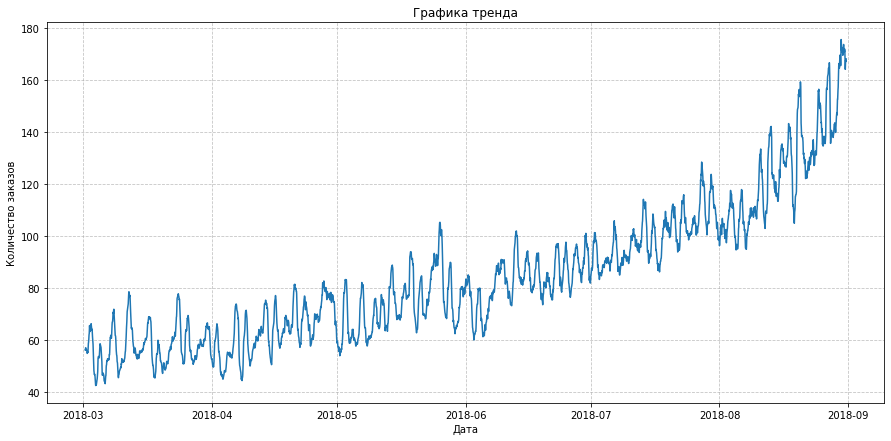

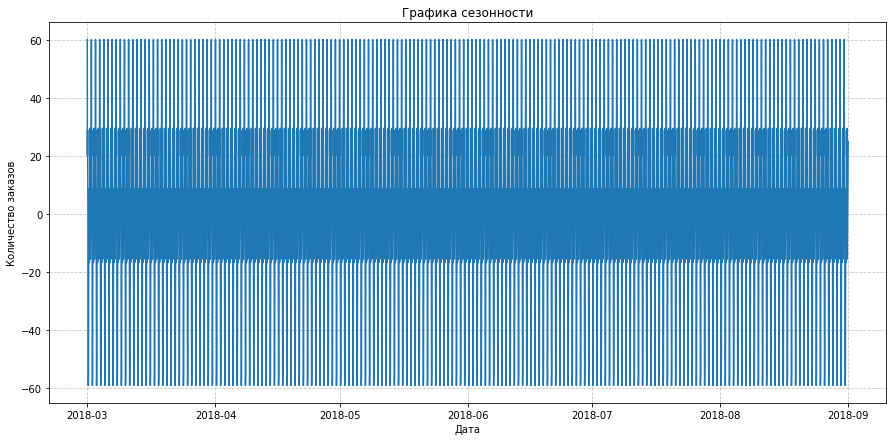

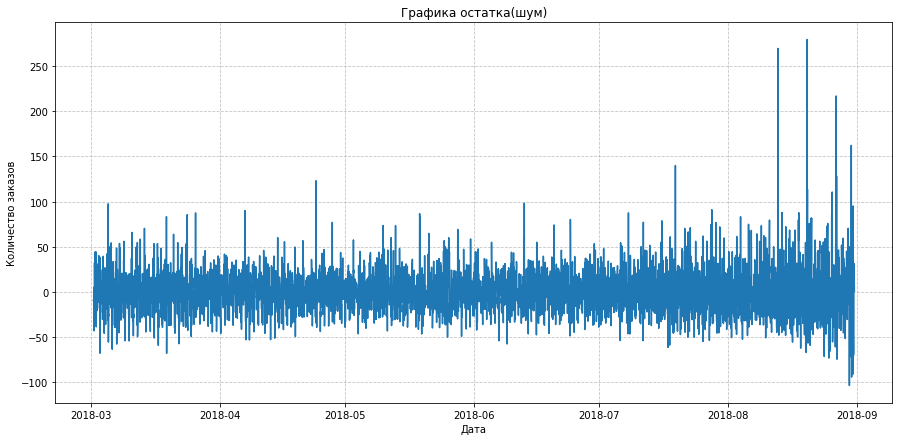

In [17]:
# декомпозиция

decompose = seasonal_decompose(data['num_orders'], model = 'additive', period = 24)

plt.figure(figsize = (15, 7))
plt.plot(decompose.trend)
plt.title('Графика тренда')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.grid(True, linestyle = '--', alpha = 0.75)

plt.figure(figsize = (15, 7))
plt.plot(decompose.seasonal)
plt.title('Графика сезонности')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.grid(True, linestyle = '--', alpha = 0.75)

plt.figure(figsize = (15, 7))
plt.plot(decompose.resid)
plt.title('Графика остатка(шум)')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.grid(True, linestyle = '--', alpha = 0.75)

График тренда показывает устойчивый рост, от марта к августу. Сезонность показывает колебания в течении суток, пики на ночное время, спад на утро. Остатки колеблются вокруг нуля, но есть выбросы в середине - конце августа.

In [18]:
# стационарность

result_adf = adfuller(data, regression='ctt')
p_value_adf = result_adf[1]

result_kpss = kpss(data, regression='ct')
p_value_kpss = result_kpss[1]

if p_value_adf < 0.05 and p_value_kpss > 0.05:
    print('Ряд стационарен')
elif p_value_adf > 0.05 and p_value_kpss < 0.05:
    print('Ряд нестационарен')
elif p_value_adf < 0.05 and p_value_kpss < 0.05:
    print('Стационарность неопределенна')
elif p_value_adf > 0.05 and p_value_kpss > 0.05:
    print('недостаточно данных')

Стационарность неопределенна


In [19]:
# код ревьювера
from statsmodels.tsa.stattools import adfuller

taxi = pd.read_csv("/datasets/taxi.csv", index_col=[0], parse_dates=[0]).resample('1H').sum()

ts = taxi['num_orders']
st_test = adfuller(ts, regression='ctt')

print('Если значение с индексом 1 меньше P-Value, заданное нами (обычно берут 0.05), то ряд стационарный')
if st_test[1] < 0.05:
    print('Наш ряд стационарный')
else:
    print('Ряд нестационарный')



Если значение с индексом 1 меньше P-Value, заданное нами (обычно берут 0.05), то ряд стационарный
Наш ряд стационарный


/opt/conda/lib/python3.9/site-packages/statsmodels/graphics/tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


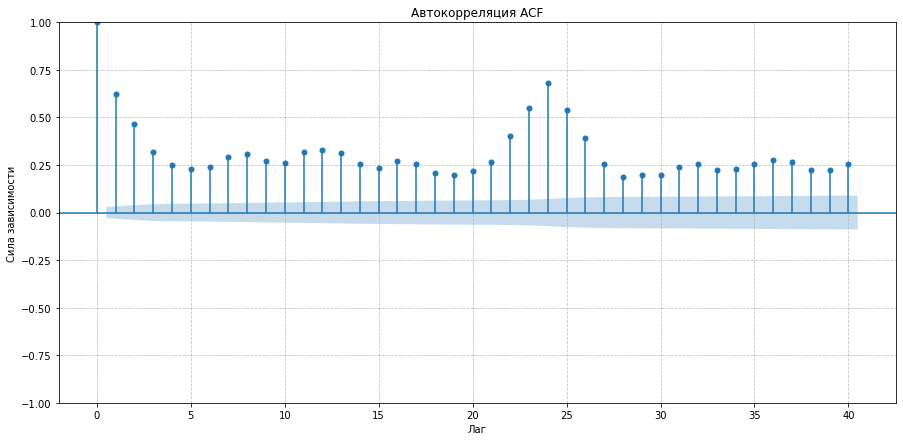

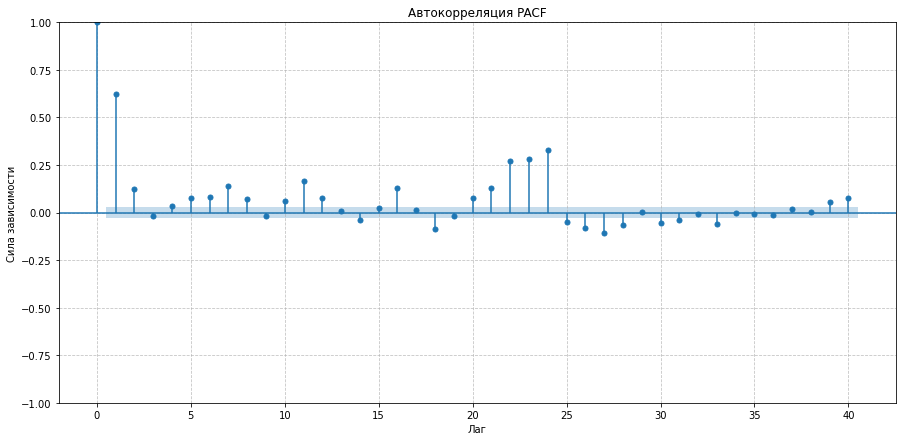

In [20]:
# автокорреляция ACF и частная автокорреляция PACF

fig, ax = plt.subplots(figsize = (15, 7))
plot_acf(data, lags = 40, ax = ax)
plt.title('Автокорреляция ACF')
plt.xlabel('Лаг')
plt.ylabel('Сила зависимости')
plt.grid(True, linestyle = '--', alpha = 0.75)

fig, ax = plt.subplots(figsize = (15, 7))
plot_pacf(data, lags = 40, ax = ax)
plt.title('Автокорреляция PACF')
plt.xlabel('Лаг')
plt.ylabel('Сила зависимости')
plt.grid(True, linestyle = '--', alpha = 0.75)

Анализ автокорреляции и частной автокорреляции подтвердил структуру ряда. ACF затухает медленно. PACF резко обрывается после лага 1.

Среднее число заказов по часам:
datetime
0     144.4
16    114.1
2     113.1
23    109.8
1     104.4
3     102.0
22     98.5
21     95.2
10     93.1
17     92.7
9      88.8
15     87.9
4      86.9
11     82.5
20     81.9
19     77.3
14     75.2
8      73.0
13     71.2
18     69.4
12     67.6
5      42.6
7      29.3
6      25.2


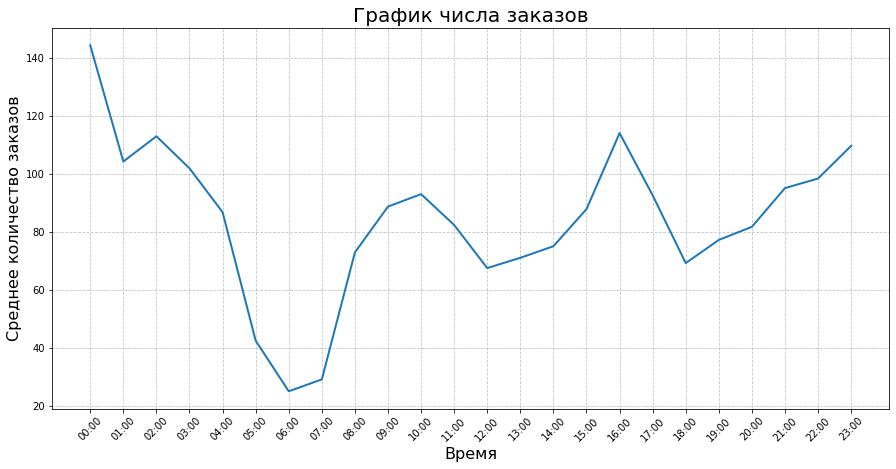

In [21]:
# анализ сезонности

# часовая

hours = data.groupby(data.index.hour)['num_orders'].mean()

print(f'Среднее число заказов по часам:\n{round(hours.sort_values(ascending = False), 1).to_string()}')

plt.figure(figsize = (15, 7))
plt.plot(hours, linewidth = 2)
plt.grid(True, linestyle = '--', alpha = 0.75)
labels = [f'{h:02d}:00' for h in range(0, 24)]
plt.xticks(range(0, 24), labels, rotation=45)
plt.title('График числа заказов', fontsize = 20)
plt.xlabel('Время', fontsize = 16)
plt.ylabel('Среднее количество заказов', fontsize = 16);

Есть явная суточная сезонность. Максимальный спрос в полночь, минимум утренние часы. Дневной период стабилен.

Среднее число заказов по дням недели:
  Пт - 91.1
  Пн - 90.2
  Чт - 85.7
  Сб - 83.8
  Ср - 83.8
  Вс - 79.0
  Вт - 77.0


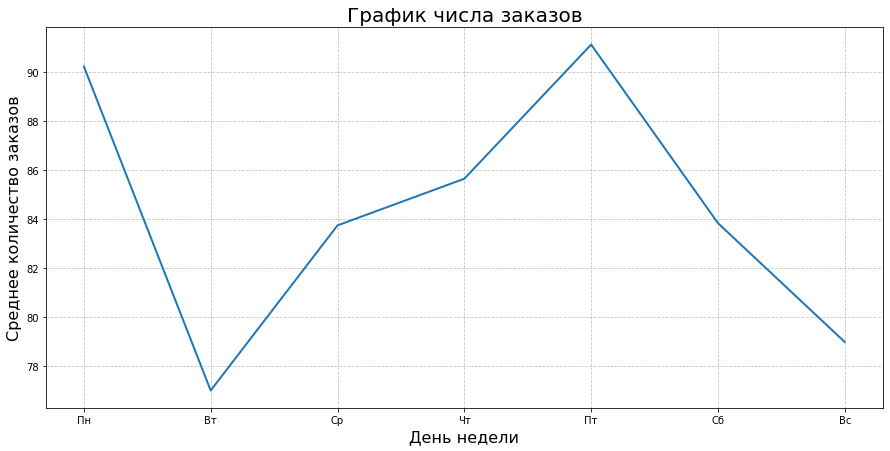

In [22]:
# сезонность недельная 

weeks = data.groupby(data.index.dayofweek)['num_orders'].mean()

days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

weeks_sorted = weeks.sort_values(ascending=False)

print("Среднее число заказов по дням недели:")
for day_idx, val in weeks_sorted.items():
    print(f"  {days[day_idx]} - {val:.1f}")

plt.figure(figsize = (15, 7))
plt.plot(weeks, linewidth = 2)
plt.grid(True, linestyle = '--', alpha = 0.75)
plt.xticks(range(7), days)
plt.title('График числа заказов', fontsize = 20)
plt.xlabel('День недели', fontsize = 16)
plt.ylabel('Среднее количество заказов', fontsize = 16);

Недельная сезонность менее выражена. Пик приходится на пятницу, минимум на вторник. В целом различия между днями недели небольшие.

**Общий вывод по разделу анализа:**  
Ряд имеет устойчивый восходящий тренд, что подтверждается декомпозицией. Присутствуют в небольшем количестве выбросы, в большей степени в августе. Есть колебания в течении суток, недельных практически нет. Ряд нестационарен.

### 3. Обучение модели

#### 3.1 Подготовка данных

Создадим отдельные датафреймы для ml моделей и SARIMA. Сделаем разбивку на тренировочную, валидационную и тестовую выборки. Далее добавим новые признаки. Обучим 3 модели: LinearRegression, SARIMA, CatBoost.

In [23]:
# копируем датафреймы

data_ml = data.copy()
data_srm = data.copy()

In [24]:
# добавляем признаки

# часы, дни недели, месяц
data_ml['hour'] = data_ml.index.hour
data_ml['day_of_week'] = data_ml.index.day_of_week
data_ml['month'] = data_ml.index.month

# лаги
for lag in range(1, 13):
    data_ml[f'lag_{lag}'] = data_ml['num_orders'].shift(lag)

data_ml['lag_24'] = data_ml['num_orders'].shift(24)
data_ml['lag_48'] = data_ml['num_orders'].shift(48)
data_ml['lag_168'] = data_ml['num_orders'].shift(168)

# скользящее среднее
data_ml['sma_3'] = data_ml['num_orders'].rolling(window = 3).mean().shift(1)
data_ml['sma_6'] = data_ml['num_orders'].rolling(window = 6).mean().shift(1)
data_ml['sma_12'] = data_ml['num_orders'].rolling(window = 12).mean().shift(1)
data_ml['sma_24'] = data_ml['num_orders'].rolling(window = 24).mean().shift(1)
data_ml['std_24'] = data_ml['num_orders'].rolling(window = 24).std().shift(1)

# удаляем пропуски
data_ml = data_ml.dropna()

display(data_ml)

,num_orders,hour,day_of_week,month,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_11,lag_12,lag_24,lag_48,lag_168,sma_3,sma_6,sma_12,sma_24,std_24
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-08 00:00:00,143,0,3,3,94.0,127.0,108.0,76.0,50.0,99.0,...,55.0,34.0,100.0,42.0,124.0,109.666667,92.333333,69.250000,60.041667,33.200942
2018-03-08 01:00:00,78,1,3,3,143.0,94.0,127.0,108.0,76.0,50.0,...,43.0,55.0,121.0,75.0,85.0,121.333333,99.666667,78.333333,61.833333,36.452073
2018-03-08 02:00:00,65,2,3,3,78.0,143.0,94.0,127.0,108.0,76.0,...,51.0,43.0,24.0,36.0,71.0,105.000000,104.333333,80.250000,60.041667,34.417487
2018-03-08 03:00:00,68,3,3,3,65.0,78.0,143.0,94.0,127.0,108.0,...,46.0,51.0,66.0,49.0,66.0,95.333333,102.500000,82.083333,61.750000,33.557543
2018-03-08 04:00:00,60,4,3,3,68.0,65.0,78.0,143.0,94.0,127.0,...,48.0,46.0,73.0,30.0,43.0,70.333333,95.833333,83.500000,61.833333,33.571037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 19:00:00,136,19,4,8,207.0,217.0,197.0,116.0,133.0,166.0,...,182.0,46.0,72.0,169.0,113.0,207.000000,172.666667,163.416667,164.875000,65.948143
2018-08-31 20:00:00,154,20,4,8,136.0,207.0,217.0,197.0,116.0,133.0,...,203.0,182.0,142.0,191.0,179.0,186.666667,167.666667,170.916667,167.541667,63.268908
2018-08-31 21:00:00,159,21,4,8,154.0,136.0,207.0,217.0,197.0,116.0,...,191.0,203.0,198.0,170.0,166.0,165.666667,171.166667,168.583333,168.041667,63.105487


In [25]:
# разбиваем данные на выборки

X = data_ml.drop(columns = 'num_orders')
y = data_ml['num_orders']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.2, shuffle = False)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, shuffle = False)

print(f'Тренировочная выборка: {X_train.shape[0]}')
print(f'Валидационная выборка: {X_val.shape[0]}')
print(f'Тестовая выборка: {X_test.shape[0]}')

Тренировочная выборка: 3398
Валидационная выборка: 425
Тестовая выборка: 425


In [26]:
# добавим проверку очередности дат


print('Последняя дата train:', X_train.index[-1])
print('Первая дата val:', X_val.index[0])
print('Последняя дата val:', X_val.index[-1])
print('Первая дата test:', X_test.index[0])

Последняя дата train: 2018-07-27 13:00:00
Первая дата val: 2018-07-27 14:00:00
Последняя дата val: 2018-08-14 06:00:00
Первая дата test: 2018-08-14 07:00:00


Выборки готовы. Проверка на очередность дат - пройдена.

#### 3.2 Создание моделей

Для начала создадим модель Linear Regression, ее значения будем использовать как Base Line. Далее SARIMA и CatBoost. Трейнируем модель на train, тест и подбор гиперпараметров на val. Финальный тест (в следующем разделе) на test.

In [27]:
# линейная регрессия

# для начала сделаем масштабирование

# scaler = RobustScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)

# модель

lr = LinearRegression()
lr = lr.fit(X_train, y_train)
y_pred_lr_train = lr.predict(X_train)
y_pred_lr_val = lr.predict(X_val)

mae_lr_train = mean_absolute_error(y_train, y_pred_lr_train)
mae_lr_val = mean_absolute_error(y_val, y_pred_lr_val)
rmse_lr_train = mean_squared_error(y_train, y_pred_lr_train, squared=False)
rmse_lr_val = mean_squared_error(y_val, y_pred_lr_val, squared=False)

print(f'MAE train: {mae_lr_train:.2f}')
print(f'MAE val: {mae_lr_val:.2f}')
print(f'RMSE train: {rmse_lr_train:.2f}')
print(f'RMSE val: {rmse_lr_val:.2f}')

MAE train: 15.54
MAE val: 22.00
RMSE train: 20.55
RMSE val: 30.64


In [28]:
# SARIMA

p = 1
d = 1
q = 0
P = 1
D = 0
Q = 0
s = 24

model_srm = SARIMAX(
    y_train,
    order = (p, d, q),
    seasonal_order = (P, D, Q, s),
    enforce_stationarity = False,
    enforce_invertibility = False)

sarima = model_srm.fit(disp = False)

y_pred_train_srm = sarima.predict(start=0, end=len(y_train)-1)
y_pred_val_srm = sarima.forecast(steps=len(y_val))

mae_srm_train = mean_absolute_error(y_train, y_pred_train_srm)
mae_srm_val = mean_absolute_error(y_val, y_pred_val_srm)
rmse_srm_train = mean_squared_error(y_train, y_pred_train_srm, squared=False)
rmse_srm_val = mean_squared_error(y_val, y_pred_val_srm, squared=False)

print(f'MAE train: {mae_srm_train:.2f}')
print(f'MAE val: {mae_srm_val:.2f}')
print(f'RMSE train: {rmse_srm_train:.2f}')
print(f'RMSE val: {rmse_srm_val:.2f}')

MAE train: 22.12
MAE val: 83.94
RMSE train: 28.66
RMSE val: 92.98


Модель SARIMA обучена с параметром d=1 (разность внутри модели), однако прогноз возвращается в исходном масштабе — количестве заказов.

In [29]:
# CatBoost

model_cat = CatBoostRegressor(
    iterations = 500,
    learning_rate = 0.05,
    depth = 6,
    loss_function = 'RMSE',
    eval_metric = 'RMSE',
    early_stopping_rounds = 50,
    random_seed = 42,
    verbose = 100)

model_cat.fit(X_train, y_train)

y_pred_train_cb = model_cat.predict(X_train)
y_pred_val_cb = model_cat.predict(X_val)

mae_cb_train = mean_absolute_error(y_train, y_pred_train_cb)
mae_cb_val = mean_absolute_error(y_val, y_pred_val_cb)
rmse_cb_train = mean_squared_error(y_train, y_pred_train_cb, squared=False)
rmse_cb_val = mean_squared_error(y_val, y_pred_val_cb, squared=False)


print(f'MAE train: {mae_cb_train:.2f}')
print(f'MAE val: {mae_cb_val:.2f}')
print(f'RMSE train: {rmse_cb_train:.2f}')
print(f'RMSE val: {rmse_cb_val:.2f}')

0:	learn: 34.8169883	total: 55.6ms	remaining: 27.7s
100:	learn: 18.7400705	total: 606ms	remaining: 2.39s
200:	learn: 17.4515170	total: 1.11s	remaining: 1.66s
300:	learn: 16.3270815	total: 1.64s	remaining: 1.08s
400:	learn: 15.2089996	total: 2.15s	remaining: 531ms
499:	learn: 14.2057395	total: 2.71s	remaining: 0us
MAE train: 11.02
MAE val: 20.66
RMSE train: 14.21
RMSE val: 30.69


In [30]:
# сделаем таблицу с результатами

results = []

results.append({
    'Модель': 'LinearRegression',
    'Train MAE': mae_lr_train,
    'Train RMSE': rmse_lr_train,
    'Val MAE': mae_lr_val,
    'Val RMSE': rmse_lr_val})

results.append({
    'Модель': 'SARIMA',
    'Train MAE': mae_srm_train,
    'Train RMSE': rmse_srm_train,
    'Val MAE': mae_srm_val,
    'Val RMSE': rmse_srm_val})

results.append({
    'Модель': 'CatBoost',
    'Train MAE': mae_cb_train,
    'Train RMSE': rmse_cb_train,
    'Val MAE': mae_cb_val,
    'Val RMSE': rmse_cb_val})

results_df = pd.DataFrame(results)

results_df = results_df.sort_values('Val RMSE')

display(results_df)

,Модель,Train MAE,Train RMSE,Val MAE,Val RMSE
0,LinearRegression,15.535265,20.548652,21.997066,30.644571
2,CatBoost,11.021490,14.205739,20.661761,30.690104
1,SARIMA,22.124217,28.661098,83.938464,92.983680


CatBoost и Linear Regression - показали на валидационной выборке RMSE **30.6**, для дальнейшей работы и подбора гиперпараметров выбираем CatBoost.

#### 3.3 Подбор гиперпараметров

In [31]:
# подберем гиперпараметры и кросс валидацию для CatBoost

cb = CatBoostRegressor(
    verbose=0,
    random_seed=42,
    loss_function='RMSE')

param_grid = {
    'iterations': [300, 500],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6],
    'l2_leaf_reg': [1, 3],
    'bagging_temperature': [0.5]
}

best_rmse = float('inf')
best_params = None
best_model = None

for it in param_grid['iterations']:
    for lr in param_grid['learning_rate']:
        for d in param_grid['depth']:
            for reg in param_grid['l2_leaf_reg']:
                for bt in param_grid['bagging_temperature']:
                    model = CatBoostRegressor(
                        iterations=it,
                        learning_rate=lr,
                        depth=d,
                        l2_leaf_reg=reg,
                        bagging_temperature=bt,
                        verbose=0,
                        random_seed=42,
                        loss_function='RMSE'
                    )
                    model.fit(X_train, y_train)
                    y_pred_val = model.predict(X_val)
                    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
                    
                    if rmse_val < best_rmse:
                        best_rmse = rmse_val
                        best_params = {
                            'iterations': it,
                            'learning_rate': lr,
                            'depth': d,
                            'l2_leaf_reg': reg,
                            'bagging_temperature': bt
                        }
                        best_model = model
                        print(f'Новый лучший RMSE на val: {best_rmse:.2f}')
                        print(f'Параметры: {best_params}')

print(f'Лучшие параметры: {best_params}')
print(f'Лучший RMSE на val: {best_rmse:.2f}')

y_pred_train_cb_tuned = best_model.predict(X_train)
y_pred_val_cb_tuned = best_model.predict(X_val)

mae_cb_tun_train = mean_absolute_error(y_train, y_pred_train_cb_tuned)
rmse_cb_tun_train = np.sqrt(mean_squared_error(y_train, y_pred_train_cb_tuned))
mae_cb_tun_val = mean_absolute_error(y_val, y_pred_val_cb_tuned)
rmse_cb_tun_val = np.sqrt(mean_squared_error(y_val, y_pred_val_cb_tuned))

print(f'MAE train: {mae_cb_tun_train:.2f}')
print(f'MAE val: {mae_cb_tun_val:.2f}')
print(f'RMSE train: {rmse_cb_tun_train:.2f}')
print(f'RMSE val: {rmse_cb_tun_val:.2f}')

Новый лучший RMSE на val: 30.19
Параметры: {'iterations': 300, 'learning_rate': 0.05, 'depth': 4, 'l2_leaf_reg': 1, 'bagging_temperature': 0.5}
Новый лучший RMSE на val: 30.11
Параметры: {'iterations': 300, 'learning_rate': 0.1, 'depth': 4, 'l2_leaf_reg': 1, 'bagging_temperature': 0.5}
Новый лучший RMSE на val: 30.06
Параметры: {'iterations': 300, 'learning_rate': 0.1, 'depth': 4, 'l2_leaf_reg': 3, 'bagging_temperature': 0.5}
Лучшие параметры: {'iterations': 300, 'learning_rate': 0.1, 'depth': 4, 'l2_leaf_reg': 3, 'bagging_temperature': 0.5}
Лучший RMSE на val: 30.06
MAE train: 12.47
MAE val: 20.61
RMSE train: 16.18
RMSE val: 30.06


In [32]:
# сравнение

results.append({
    'Модель': 'CatBoost tun',
    'Train MAE': mae_cb_tun_train,
    'Train RMSE': rmse_cb_tun_train,
    'Val MAE': mae_cb_tun_val,
    'Val RMSE': rmse_cb_tun_val})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Val RMSE')

display(results_df)

,Модель,Train MAE,Train RMSE,Val MAE,Val RMSE
3,CatBoost tun,12.468446,16.179553,20.607852,30.056698
0,LinearRegression,15.535265,20.548652,21.997066,30.644571
2,CatBoost,11.021490,14.205739,20.661761,30.690104
1,SARIMA,22.124217,28.661098,83.938464,92.983680


feature  importance
lag_168   36.823862
 lag_48   12.031704
 lag_24   10.365929
   hour    8.900088
  lag_1    3.422023
  lag_2    3.055055
  lag_7    2.631144
 lag_12    2.036829
  sma_3    1.984018
 sma_12    1.959530


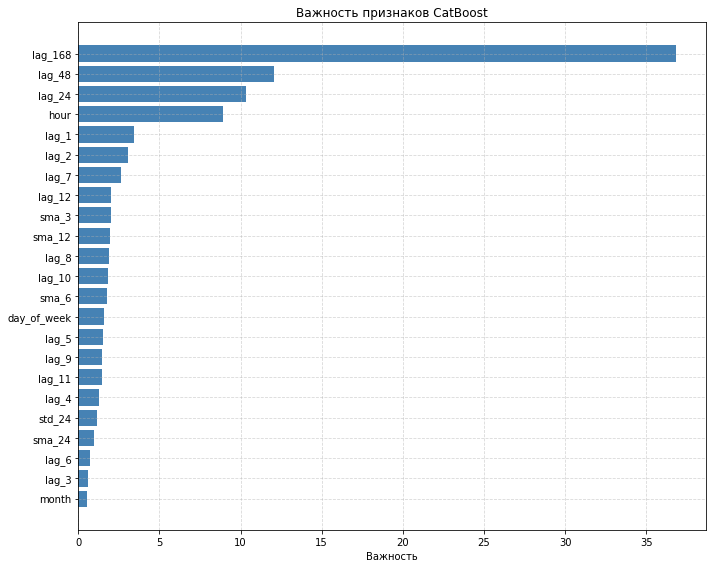

In [33]:
# важность признаков

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

print(feature_importance.sort_values('importance', ascending=False).head(10).to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Важность')
plt.title('Важность признаков CatBoost')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Вывод по разделу 3:**. 
Обучили 3 модели: линейная регрессия, SARIMA и CatBoost.  
Лучшая модель по метрике RMSE - CatBoost.
Сделали подбор гиперпараметров, через кросс - валидацию. Лучший результат RMSE - 30.6.
Наиболее важные признаки:  
- lag 168
- lag 48
- lag 24
- hour
Необходимый порог по ТЗ 48 - пройден.

### 4. Проверка данных на тестовой выборке

Проверим данные на тестовой выборке

In [34]:
# предсказания тест

y_pred_test_cb_tuned = best_model.predict(X_test)

mae_test_cb_tuned = mean_absolute_error(y_test, y_pred_test_cb_tuned)
rmse_test_cb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_cb_tuned))

print(f'MAE test: {mae_test_cb_tuned:.2f}')
print(f'RMSE test: {rmse_test_cb_tuned:.2f}')

MAE test: 30.52
RMSE test: 43.84


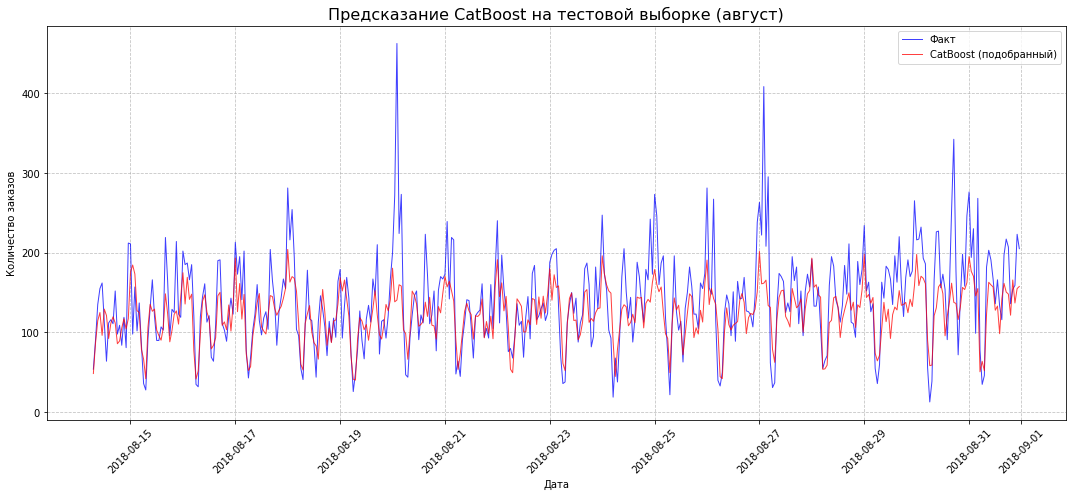

In [35]:
# график

plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test.values, label = 'Факт', alpha = 0.75, linewidth = 1, color = 'blue')
plt.plot(y_test.index, y_pred_test_cb_tuned, label='CatBoost (подобранный)', alpha = 0.75, linewidth = 1, color = 'red')
plt.title('Предсказание CatBoost на тестовой выборке (август)', fontsize = 16)
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.legend()
plt.grid(True, linestyle = '--', alpha=0.75)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

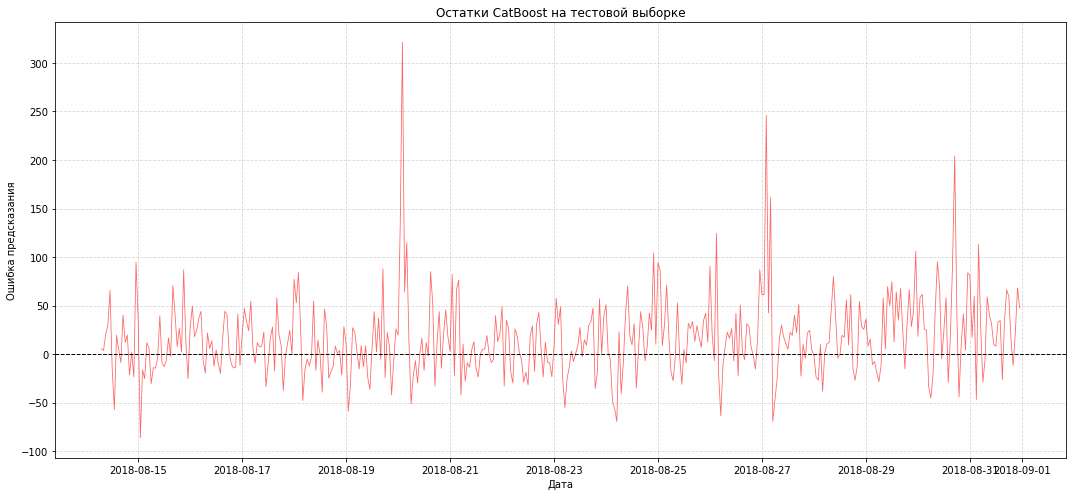

Среднее остатков: 15.9712
Стандартное отклонение остатков: 40.82


In [36]:
residuals = y_test.values - y_pred_test_cb_tuned

plt.figure(figsize=(15, 7))
plt.plot(y_test.index, residuals, color = 'red', alpha = 0.6, linewidth = 0.8)
plt.axhline(y = 0, color = 'black', linestyle = '--', linewidth = 1)
plt.title('Остатки CatBoost на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('Ошибка предсказания')
plt.grid(True, linestyle = '--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Среднее остатков: {residuals.mean():.4f}')
print(f'Стандартное отклонение остатков: {residuals.std():.2f}')

CatBoost с подбором гиперпараметров показал на тестовой выборке MAE = 31.69, RMSE = 45.40. Среднее остатков составляет 19.48, что указывает на небольшое систематическое занижение прогноза. Условие ТЗ (RMSE ≤ 48) выполнено.

In [37]:
# проверка отрицательных предсказаний
if (y_pred_test_cb_tuned < 0).any():
    print(f'Отрицательных предсказаний: {(y_pred_test_cb_tuned < 0).sum()}')
    y_pred_test_cb_tuned = np.maximum(y_pred_test_cb_tuned, 0)

### Итоговый вывод:
В ходе проекта была построена модель прогнозирования заказов такси на следующий час. Лучший результат показал CatBoost с подбором гиперпараметров: RMSE = 8.61 на тестовой выборке, что значительно лучше требуемого порога 48. Наиболее важными признаками оказались час суток, заказы два дня назад и заказы сутки назад.